In this notebook we test Vanguri et al. architecture on the I3LUNG data. 


# Set-up

In [5]:
import pandas as pd
import os
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
from lung_helpers import train, get_training_data, train_standard_split, hyperparameter_search

In [6]:
if not 'summary_dfs' in locals():
    print ("init summary_dfs")
    summary_dfs = {}

In [7]:
DATA_DIR = "../../data"
RESULTS_DIR = "./results"

os.makedirs(RESULTS_DIR, exist_ok=True)

In [8]:
df_outcomes = pd.read_csv(f"{DATA_DIR}/outcomes.csv")
df_outcomes = df_outcomes.rename(columns={'Subject': 'main_index'}).set_index('main_index')

# Find coumns with 2075 label non-null
outcome_cols_complete = []
for col in df_outcomes.columns:
    n_valid = df_outcomes[col].notna().sum()
    print(f"{col}: {n_valid} non-null")
    if n_valid == 2075:
        outcome_cols_complete.append(col)


DEATH EVENT: 2075 non-null
PROGRESSION EVENT: 2070 non-null
THERAPY END EVENT: 2075 non-null
BEST RESPONSE: 2068 non-null
IO LINE: 2075 non-null
IO IOCHT: 2075 non-null
HISTOLOGY SQUAMOUS: 2052 non-null
HISTOLOGY ADENOCARCINOMA: 2052 non-null
ORR: 2068 non-null
DCR: 2068 non-null
CBR: 2066 non-null
PFS MONTHS: 2066 non-null
OS MONTHS: 2074 non-null
TTF MONTHS: 2073 non-null
OS_6: 1972 non-null
OS_24: 1699 non-null


In [9]:
# complete cohort
df_clinical_full = pd.read_csv(f"{DATA_DIR}/cb_processed.csv")
df_clinical_full = df_clinical_full.rename(columns={'Subject': 'main_index'})

# Cohort2 (IO LINE == 1)
df_cb = pd.read_csv(f"{DATA_DIR}/cb.csv")
df_cb_cohort2 = df_cb[df_cb['IO LINE'] == 1].copy()

cohorts = {
    'cohort23': {
        'subjects': df_clinical_full['main_index'].values,
        'split_source': df_clinical_full
    },
    'cohort2': {
        'subjects': df_cb_cohort2['Subject'].values,
        'split_source': df_cb_cohort2.rename(columns={'Subject': 'main_index'})
    }
}

all_splits = {}

for cohort_name, cohort_info in cohorts.items():
    print(f"\n{'='*50}")
    print(f"Processing {cohort_name}")
    print(f"{'='*50}")
    
    # filter df_clinical_full for the subjects in the cohort
    cohort_subjects = cohort_info['subjects']
    df_clinical = df_clinical_full[df_clinical_full['main_index'].isin(cohort_subjects)].copy()
    
    # extract splits
    split_df = cohort_info['split_source']
    train_df = split_df[split_df['SET'] == 'TRAIN']
    test_df = split_df[split_df['SET'] == 'TEST']
    ext_val_df = split_df[split_df['SET'] == 'EXVAL']
    
    train_px = train_df['main_index'].values
    test_px = test_df['main_index'].values
    ext_val_px = ext_val_df['main_index'].values
    
    print(f"=== INITIAL SPLIT {cohort_name} ===")
    print(f"Train: {len(train_px)}, Test: {len(test_px)}, ExtVal: {len(ext_val_px)}")
    
    # extract predefined folds (exclude UOC from training centers)
    predefined_folds = train_df[train_df['CENTER'] != 'UOC'][['main_index', 'CENTER']].rename(columns={'CENTER': 'fold'})
    predefined_folds = predefined_folds.set_index('main_index')
    
    print(f"Train Centers (per CV): {predefined_folds['fold'].unique()}")
    print(f"Patients for center:\n{predefined_folds['fold'].value_counts()}")
    
    # prepare clinical dataframe
    df_clinical = df_clinical.set_index('main_index')
    df_clinical = df_clinical.drop(columns=['CENTER', 'SET'], errors='ignore')
    
    # save for later use
    all_splits[cohort_name] = {
        'df_clinical': df_clinical,
        'train_px': train_px,
        'test_px': test_px,
        'ext_val_px': ext_val_px,
        'predefined_folds': predefined_folds
    }


Processing cohort23
=== INITIAL SPLIT cohort23 ===
Train: 1550, Test: 274, ExtVal: 251
Train Centers (per CV): ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
Patients for center:
fold
INT     582
GHD     365
SZMC    232
MH      196
VHIO    175
Name: count, dtype: int64

Processing cohort2
=== INITIAL SPLIT cohort2 ===
Train: 1046, Test: 181, ExtVal: 210
Train Centers (per CV): ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
Patients for center:
fold
INT     386
GHD     231
SZMC    193
MH      164
VHIO     72
Name: count, dtype: int64


In [10]:
df_pyrad = pd.read_csv(f"{DATA_DIR}/pyradiomics.csv")
df_pyrad = df_pyrad.rename(columns={'Subject': 'main_index'})

print(f"total patients: {len(df_pyrad)}")

# Set index e drop colonne
df_pyrad = df_pyrad.set_index('main_index')
df_pyrad = df_pyrad.drop(columns=['CENTER', 'SET'], errors='ignore')

print(f"pyradiomics features: {len(df_pyrad.columns)}")

total patients: 877
pyradiomics features: 128


In [11]:
df_fmrad = pd.read_csv(f"{DATA_DIR}/fmrad.csv")
df_fmrad = df_fmrad.rename(columns={'Subject': 'main_index'})

print(f"total patients: {len(df_fmrad)}")
# Set index e drop columns
df_fmrad = df_fmrad.set_index('main_index')
df_fmrad = df_fmrad.drop(columns=['CENTER', 'SET'], errors='ignore')

print(f"fmradiomics features: {len(df_fmrad.columns)}")

total patients: 896
fmradiomics features: 4096


In [12]:
df_pathology = pd.read_csv(f"{DATA_DIR}/digital_pathology_processed.csv")  
df_pathology = df_pathology.rename(columns={'Subject': 'main_index'})  

print(f"total patients: {len(df_pathology)}")

# Set index e drop columns
df_pathology = df_pathology.set_index('main_index')
df_pathology = df_pathology.drop(columns=['CENTER', 'SET'], errors='ignore')  

print(f"pathology features: {len(df_pathology.columns)}")

total patients: 846
pathology features: 768


In [13]:
df_genomics = pd.read_csv(f"{DATA_DIR}/genomics_processed.csv") 
df_genomics = df_genomics.rename(columns={'Subject': 'main_index'})  

print(f"total patients: {len(df_genomics)}")

# Set index e drop columns
df_genomics = df_genomics.set_index('main_index')
df_genomics = df_genomics.drop(columns=['CENTER', 'SET'], errors='ignore')

print(f"genomics features: {len(df_genomics.columns)}")

total patients: 1705
genomics features: 4


In [14]:
df_outcomes = pd.read_csv(f"{DATA_DIR}/outcomes.csv")
df_outcomes = df_outcomes.rename(columns={'Subject': 'main_index'})
df_outcomes = df_outcomes.set_index('main_index')
df_outcomes = df_outcomes[~df_outcomes.index.duplicated()]
print("total patients:", df_outcomes.index.nunique())
print(f"total outcomes: {len(df_outcomes.columns)}")

total patients: 2075
total outcomes: 16


# Hyperparam search

default hyperparam from original paper

In [11]:
# for multimodal models, attention gate
model_params = {'epochs':125, 'lr':0.01, 'alpha':0.001, 'beta':0.0, 'cross_modality_enabled':False}
# for unimodal models, no attention gate
model_params_gate_off = {'epochs':125, 'lr':0.01, 'alpha':0.001, 'beta':0.0, 'cross_modality_enabled':False, 'attention_gate_enabled':False}

hyperparam grid

In [15]:
hyperparam_grid = {
    'epochs': [100, 125, 150],
    'lr': [0.001, 0.01, 0.1],
    'alpha': [0.0001, 0.001, 0.01],  # L2 weight
    'beta': [0.0, 0.001, 0.01]       # AR2 weight
}

We perform hyperparameter search following the Vanguri method. We split the training data by reserving 10% as a validation set and using the remaining 90% for training. Each combination of hyperparameters is trained on the 90% training subset and evaluated on the 10% validation subset. We select the best-performing hyperparameter set based on the highest AUC score on the validation set, where "best performing" is defined as the configuration that achieves the highest AUC with a confidence interval that does not overlap with those of other configurations. We selected the hyperparameters on the largest cohort of patients with the most modalities.

In [16]:
# Prepare data for cohort23, OS_6
cohort_name = 'cohort23'
outcome_col = 'OS_6'

df_clinical_clean = all_splits[cohort_name]['df_clinical'].copy()
train_px = all_splits[cohort_name]['train_px']

# Filtra solo train set
df_clinical_train = df_clinical_clean.loc[train_px]

cohort_subjects = df_clinical_train.index
df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()

df_dyam = df_clinical_train.copy()
df_dyam['label'] = df_outcomes[outcome_col]
df_dyam = df_dyam.dropna(subset=['label'])

X_clin = df_dyam.drop(columns=['label']).fillna(0)
X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)

modality_mask = pd.DataFrame({
    'clinical': 1,
    'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
    'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
    'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
}, index=df_dyam.index)

df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)

# L1 filter
df_rad_for_filter = X_rad.reset_index()
df_rad_for_filter['job_tag'] = 'filtered-radiomics'
df_rad_for_filter['site'] = 'PC'
df_rad_for_filter['lesion_index'] = 1

dfs_filters = {
    1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
}

# Run hyperparameter search
best_params, search_results = hyperparameter_search(
    [X_clin, X_rad, X_path, X_gen],
    modality_mask, 
    df_out,
    dfs_filters,
    hyperparam_grid
)

# Save results
search_results.to_csv('results/hyperparam_search_results_cohort23_OS_6.csv', index=False)

print(f"\nUsing best parameters for all models: {best_params}")

Testing 81 combinations
Train: 1325, Validation: 148

Train samples: 1325
Test samples: 148
Applying L1 filter on modality position 1
Selected 17 outlier-stable features
Training 100 epochs with 6 batches
Final output - min: -0.9600, max: 0.8659, mean: 0.0176
Training mode - mu: -0.0101, std: 0.3353
Eval mode - using mu: -0.0101, std: 0.3353
Eval mode - using mu: -0.0101, std: 0.3353

Test AUC: 0.648 (95% CI: 0.548-0.747)
epochs=100, lr=0.001, alpha=0.0001, beta=0.0 -> Val AUC: 0.658 (95% CI: 0.629-0.688)
  -> New best (no CI overlap)
Train samples: 1325
Test samples: 148
Applying L1 filter on modality position 1
Selected 17 outlier-stable features
Training 100 epochs with 6 batches
Final output - min: -0.9657, max: 0.9023, mean: 0.0462
Training mode - mu: 0.0366, std: 0.3271
Eval mode - using mu: 0.0366, std: 0.3271
Eval mode - using mu: 0.0366, std: 0.3271

Test AUC: 0.649 (95% CI: 0.554-0.744)
epochs=100, lr=0.001, alpha=0.0001, beta=0.001 -> Val AUC: 0.672 (95% CI: 0.644-0.701)
  -

KeyboardInterrupt: 

In [17]:
# for multimodal models, attention gate
model_params = {'epochs': 125, 'lr': 0.1, 'alpha': 0.0001, 'beta': 0.0, 'cross_modality_enabled': False}
# for unimodal models, no attention gate
model_params_gate_off = {'epochs':125, 'lr':0.01, 'alpha':0.0001, 'beta':0.0, 'cross_modality_enabled':False, 'attention_gate_enabled':False}

# Unimodal clinical

cross validation unimodal

In [18]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training models for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        X_dyam = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_dyam.isna().sum().sum()}")
        
        modality_mask_single = pd.DataFrame({
            'clinical': X_dyam.notna().any(axis=1).astype(int)
        }, index=X_dyam.index)
        print(f"Modality mask created with {modality_mask_single['clinical'].sum()} samples having clinical data")
        
        X_dyam_filled = X_dyam.fillna(0)
        print(f"After filling missing values: {X_dyam_filled.isna().sum().sum()} missing values")
        
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        common_index = X_dyam_filled.index & modality_mask_single.index & df_out.index
        X_dyam_filled = X_dyam_filled.loc[common_index]
        modality_mask_single = modality_mask_single.loc[common_index]
        df_out = df_out.loc[common_index]
        
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        cv_index = predefined_folds_aligned.index
        X_dyam_cv = X_dyam_filled.loc[cv_index]
        modality_mask_cv = modality_mask_single.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        summary_dfs[f'{cohort_name}_Clinical_{outcome_col}'], _ = train(
            modality_list_in=[X_dyam_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter={},
            model_params=model_params_gate_off,
            predefined_folds=predefined_folds_aligned
        )
        
        summary_dfs[f'{cohort_name}_Clinical_{outcome_col}'].to_csv(
            f'results/cv_cb_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training models for cohort23

--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Modality mask created with 2066 samples having clinical data
After filling missing values: 0 missing values
Predefined folds after alignment: 1542 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1542 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 365 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (1177 samples)
Fold INT (test): 579 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (963 samples)
Fold MH (test): 194 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1348 samples)
Fold SZMC (test): 230 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1312 samples)
Fold VHIO (test): 174 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1

train/test/ext-val unimodal

In [19]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training models for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:

        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Feature matrix
        X_dyam = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_dyam.isna().sum().sum()}")
        
        # Modality mask
        modality_mask_single = pd.DataFrame({
            'clinical': X_dyam.notna().any(axis=1).astype(int)
        }, index=X_dyam.index)
        print(f"Modality mask created with {modality_mask_single['clinical'].sum()} samples having clinical data")
        
        # Fill missing
        X_dyam_filled = X_dyam.fillna(0)
        print(f"After filling missing values: {X_dyam_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_dyam_filled.index & modality_mask_single.index & df_out.index
        X_dyam_filled = X_dyam_filled.loc[common_index]
        modality_mask_single = modality_mask_single.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # Train
        summary_dfs[f'{cohort_name}_Clinical_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_dyam_filled],
            modality_mask=modality_mask_single,
            outcomes=df_out,
            l1_dfs_filter={},
            model_params=model_params_gate_off,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Salva predizioni
        summary_dfs[f'{cohort_name}_Clinical_{outcome_col}'].to_csv(
            f'results/standard_cb_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training models for cohort23

--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Modality mask created with 2066 samples having clinical data
After filling missing values: 0 missing values
After filtering - Train: 1542, Test: 273, ExtVal: 251
Train samples: 1542
Test samples: 273
External validation samples: 251
Training 125 epochs with 7 batches
Final output - min: -0.9999, max: 1.0000, mean: -0.0105
Training mode - mu: 0.0504, std: 0.6405
Eval mode - using mu: 0.0504, std: 0.6405
Eval mode - using mu: 0.0504, std: 0.6405

Test AUC: 0.697 (95% CI: 0.635-0.759)
Eval mode - using mu: 0.0504, std: 0.6405
External Validation AUC: 0.679 (95% CI: 0.613-0.745)


Training models for cohort2

--- Processing outcome: CBR for cohort2 ---
Processing outcome: CBR, initial samples: 1437
After dropping missing labels: 1430 samples
Initial missing values in features: 0
Modality 

# Bimodal Clinical + Radiomics

bimodal clinical + pyrad cross validation

In [20]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']

    print(f"Clinical samples for {cohort_name}: {len(df_clinical_clean)}")
    
    # Filtra radiology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()

    print(f"Radiology samples for {cohort_name}: {len(df_radiology_clean)}")
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology (allineato con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_bimodal['radiology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad.fillna(0)
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align / saftey check 
        common_index = X_clin_filled.index & X_rad_filled.index & modality_mask_bimodal.index & df_out.index
        print(f"Common index samples: {len(common_index)}")
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]

        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")

        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue


        # Filter for CV 
        X_clin_cv = X_clin_filled.loc[predefined_folds_aligned.index]
        X_rad_cv = X_rad_filled.loc[predefined_folds_aligned.index]
        modality_mask_cv = modality_mask_bimodal.loc[predefined_folds_aligned.index]
        df_out_cv = df_out.loc[predefined_folds_aligned.index]

        
        # L1 filter
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        dfs_rad_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+Rad_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_rad_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad_{outcome_col}'].to_csv(
            f'results/cv_cb_pyrad_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models for cohort23
Clinical samples for cohort23: 2075
Radiology samples for cohort23: 877

--- Processing outcome: CBR for cohort23 ---
Patients with CBR label: 2066
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 875
Common index samples: 2066
Predefined folds after alignment: 1542 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 365 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (1177 samples)
Fold INT (test): 579 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (963 samples)
Fold MH (test): 194 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1348 samples)
Fold SZMC (test): 230 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1312 samples)
Fold VHIO (test): 174 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1368 samples)
  0%|          | 0/5 [00:00<?, ?it/s]
P

Final output - min: -1.0000, max: 1.0000, mean: -0.0385
Training mode - mu: -0.0210, std: 0.8291
Eval mode - using mu: -0.0210, std: 0.8291
 20%|██        | 1/5 [00:02<00:09,  2.32s/it]
Processing fold 2: 963 train samples, 579 validation samples
 Applying L1 filter on modality position 1
Selected 17 outlier-stable features
Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.0503
Training mode - mu: -0.0748, std: 0.7105
Eval mode - using mu: -0.0748, std: 0.7105
 40%|████      | 2/5 [00:04<00:06,  2.02s/it]
Processing fold 3: 1348 train samples, 194 validation samples
 Applying L1 filter on modality position 1
Selected 13 outlier-stable features
Training 125 epochs with 6 batches
Final output - min: -0.9999, max: 0.9994, mean: -0.0821
Training mode - mu: -0.0604, std: 0.6592
Eval mode - using mu: -0.0604, std: 0.6592
 60%|██████    | 3/5 [00:06<00:04,  2.36s/it]
Processing fold 4: 1312 train samples, 230 validation samples
 Applying L1 filter on modali

bimodal clinical + pyrad train/test/ext_val split 

In [21]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology (allineato con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_bimodal['radiology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filter setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        dfs_rad_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+Rad_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled],
            modality_mask=modality_mask_bimodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_rad_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad_{outcome_col}'].to_csv(
            f'results/standard_cb_pyrad_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (standard split) for cohort23

--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 875
After filling missing values: 0 missing values
After filtering - Train: 1542, Test: 273, ExtVal: 251
Train samples: 1542
Test samples: 273
External validation samples: 251
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 7 batches
Final output - min: -1.0000, max: 1.0000, mean: 0.0387
Training mode - mu: 0.1191, std: 0.7629
Eval mode - using mu: 0.1191, std: 0.7629
Eval mode - using mu: 0.1191, std: 0.7629

Test AUC: 0.664 (95% CI: 0.600-0.728)
Eval mode - using mu: 0.1191, std: 0.7629
External Validation AUC: 0.659 (95% CI: 0.592-0.727)


Training bimodal models (standard split) for cohort2

--- Processing outcome: CBR 

bimodal clinical + fmrad cross validation

In [ ]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (FM radiology) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology (allineato con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_bimodal['radiology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        modality_mask_cv = modality_mask_bimodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filter
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        dfs_rad_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_rad_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM_{outcome_col}'].to_csv(
            f'results/cv_cb_radfm_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (FM radiology) for cohort23

--- Processing outcome: CBR for cohort23 ---
Patients with CBR label: 2066
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 894
Predefined folds after alignment: 1542 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1542 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 365 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (1177 samples)
Fold INT (test): 579 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (963 samples)
Fold MH (test): 194 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1348 samples)
Fold SZMC (test): 230 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1312 samples)
Fold VHIO (test): 174 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1368 samples)
  0%|          | 0/5 [00:00<?, ?it/s]
Processing fold 1: 1177 train samples, 365 v

bimodal clinical + fmrad train/test/ext_val

In [22]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (FM radiology, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology (allineato con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_bimodal['radiology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filter setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        dfs_rad_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled],
            modality_mask=modality_mask_bimodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_rad_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM_{outcome_col}'].to_csv(
            f'results/standard_cb_radfm_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (FM radiology, standard split) for cohort23

--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 894
After filling missing values: 0 missing values
After filtering - Train: 1542, Test: 273, ExtVal: 251
Train samples: 1542
Test samples: 273
External validation samples: 251
Applying L1 filter on modality position 1
Selected 3609 outlier-stable features
Training 125 epochs with 7 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1123
Training mode - mu: -0.0668, std: 0.7727
Eval mode - using mu: -0.0668, std: 0.7727
Eval mode - using mu: -0.0668, std: 0.7727

Test AUC: 0.672 (95% CI: 0.609-0.736)
Eval mode - using mu: -0.0668, std: 0.7727
External Validation AUC: 0.669 (95% CI: 0.601-0.737)


Training bimodal models (FM radiology, standard split) for c

# Bimodal Clinical + Digital Pathology

bimodal clinical + dp cross validation

In [23]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (pathology) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features pathology (allineato con reindex)
        X_dp = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with pathology data: {modality_mask_bimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_dp_filled = X_dp
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_dp_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_dp_filled = X_dp_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_dp_cv = X_dp_filled.loc[cv_index]
        modality_mask_cv = modality_mask_bimodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+DP_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_dp_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter={},
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+DP_{outcome_col}'].to_csv(
            f'results/cv_cb_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (pathology) for cohort23

--- Processing outcome: CBR for cohort23 ---
Patients with CBR label: 2066
Total patients: 2066
Patients with clinical data: 2066
Patients with pathology data: 843
Predefined folds after alignment: 1542 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1542 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 365 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (1177 samples)
Fold INT (test): 579 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (963 samples)
Fold MH (test): 194 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1348 samples)
Fold SZMC (test): 230 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1312 samples)
Fold VHIO (test): 174 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1368 samples)
  0%|          | 0/5 [00:00<?, ?it/s]
Processing fold 1: 1177 train samples, 365 vali

bimodal clinical + dp standard

In [24]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training bimodal models (pathology, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features pathology (allineato con reindex)
        X_dp = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_bimodal = pd.DataFrame({
            'clinical': 1,
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_bimodal['clinical'].sum()}")
        print(f"Patients with pathology data: {modality_mask_bimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_dp_filled = X_dp
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_dp_filled.index & modality_mask_bimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_dp_filled = X_dp_filled.loc[common_index]
        modality_mask_bimodal = modality_mask_bimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # Train bimodal
        summary_dfs[f'{cohort_name}_Clinical+DP_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_dp_filled],
            modality_mask=modality_mask_bimodal,
            outcomes=df_out,
            l1_dfs_filter={},
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+DP_{outcome_col}'].to_csv(
            f'results/standard_cb_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training bimodal models (pathology, standard split) for cohort23

--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Total patients: 2066
Patients with clinical data: 2066
Patients with pathology data: 843
After filling missing values: 0 missing values
After filtering - Train: 1542, Test: 273, ExtVal: 251
Train samples: 1542
Test samples: 273
External validation samples: 251
Training 125 epochs with 7 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.0373
Training mode - mu: 0.0352, std: 0.8343
Eval mode - using mu: 0.0352, std: 0.8343
Eval mode - using mu: 0.0352, std: 0.8343

Test AUC: 0.703 (95% CI: 0.641-0.764)
Eval mode - using mu: 0.0352, std: 0.8343
External Validation AUC: 0.594 (95% CI: 0.524-0.664)


Training bimodal models (pathology, standard split) for cohort2

--- Processing outcome: CBR for cohort2 ---
Processing outcome: CBR, initial sampl

Final output - min: -1.0000, max: 1.0000, mean: 0.0463
Training mode - mu: 0.1531, std: 0.8319
Eval mode - using mu: 0.1531, std: 0.8319
Eval mode - using mu: 0.1531, std: 0.8319

Test AUC: 0.657 (95% CI: 0.576-0.738)
Eval mode - using mu: 0.1531, std: 0.8319
External Validation AUC: 0.531 (95% CI: 0.453-0.609)



# Trimodal Clinical + Radiomics + Digital Pathology

trimodal clinical + pyrad + dp cross validation

In [25]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training trimodal models (clinical+radiology+pathology) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology e pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology e pathology (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_trimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_trimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_trimodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_trimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & modality_mask_trimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        modality_mask_trimodal = modality_mask_trimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        X_path_cv = X_path_filled.loc[cv_index]
        modality_mask_cv = modality_mask_trimodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filters
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train trimodal
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv, X_path_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp_{outcome_col}'].to_csv(
            f'results/cv_cb_pyrad_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training trimodal models (clinical+radiology+pathology) for cohort23

--- Processing outcome: CBR for cohort23 ---
Patients with CBR label: 2066
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 875
Patients with pathology data: 843
Predefined folds after alignment: 1542 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1542 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 365 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (1177 samples)
Fold INT (test): 579 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (963 samples)
Fold MH (test): 194 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1348 samples)
Fold SZMC (test): 230 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1312 samples)
Fold VHIO (test): 174 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1368 samples)
  0%|          | 0/5 [00:00<?, 

Final output - min: -1.0000, max: 1.0000, mean: 0.1080
Training mode - mu: 0.1714, std: 0.7783
Eval mode - using mu: 0.1714, std: 0.7783
 20%|██        | 1/5 [00:04<00:17,  4.30s/it]
Processing fold 2: 656 train samples, 384 validation samples
 Applying L1 filter on modality position 1
Selected 18 outlier-stable features
Training 125 epochs with 3 batches
Final output - min: -1.0000, max: 1.0000, mean: 0.0349
Training mode - mu: 0.0390, std: 0.7937
Eval mode - using mu: 0.0390, std: 0.7937
 40%|████      | 2/5 [00:08<00:12,  4.06s/it]
Processing fold 3: 878 train samples, 162 validation samples
 Applying L1 filter on modality position 1
Selected 13 outlier-stable features
Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: 0.0011
Training mode - mu: 0.0184, std: 0.7305
Eval mode - using mu: 0.0184, std: 0.7305
 60%|██████    | 3/5 [00:13<00:09,  4.59s/it]
Processing fold 4: 848 train samples, 192 validation samples
 Applying L1 filter on modality position

trimodal clinical + pyrad + dp train/test/extval split

In [26]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training trimodal models (clinical+radiology+pathology, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology e pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology e pathology (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_trimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_trimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_trimodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_trimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & modality_mask_trimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        modality_mask_trimodal = modality_mask_trimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filters setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train trimodal
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled, X_path_filled],
            modality_mask=modality_mask_trimodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp_{outcome_col}'].to_csv(
            f'results/standard_cb_pyrad_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training trimodal models (clinical+radiology+pathology, standard split) for cohort23

--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 875
Patients with pathology data: 843
After filling missing values: 0 missing values
After filtering - Train: 1542, Test: 273, ExtVal: 251
Train samples: 1542
Test samples: 273
External validation samples: 251
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 7 batches


Final output - min: -1.0000, max: 1.0000, mean: -0.0080
Training mode - mu: 0.1215, std: 0.7616
Eval mode - using mu: 0.1215, std: 0.7616
Eval mode - using mu: 0.1215, std: 0.7616

Test AUC: 0.678 (95% CI: 0.615-0.742)
Eval mode - using mu: 0.1215, std: 0.7616
External Validation AUC: 0.658 (95% CI: 0.590-0.726)


Training trimodal models (clinical+radiology+pathology, standard split) for cohort2

--- Processing outcome: CBR for cohort2 ---
Processing outcome: CBR, initial samples: 1437
After dropping missing labels: 1430 samples
Initial missing values in features: 0
Total patients: 1430
Patients with clinical data: 1430
Patients with radiology data: 561
Patients with pathology data: 633
After filling missing values: 0 missing values
After filtering - Train: 1040, Test: 180, ExtVal: 210
Train samples: 1040
Test samples: 180
External validation samples: 210
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 5 batches
Final output - min:

trimodal clinical + fmrad + dp cross val

In [27]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training trimodal models (clinical+FM radiology+pathology) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology e pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology e pathology (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_trimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_trimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_trimodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_trimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & modality_mask_trimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        modality_mask_trimodal = modality_mask_trimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        X_path_cv = X_path_filled.loc[cv_index]
        modality_mask_cv = modality_mask_trimodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filters
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train trimodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv, X_path_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp_{outcome_col}'].to_csv(
            f'results/cv_cb_radfm_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training trimodal models (clinical+FM radiology+pathology) for cohort23

--- Processing outcome: CBR for cohort23 ---
Patients with CBR label: 2066
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 894
Patients with pathology data: 843
Predefined folds after alignment: 1542 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1542 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 365 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (1177 samples)
Fold INT (test): 579 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (963 samples)
Fold MH (test): 194 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1348 samples)
Fold SZMC (test): 230 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1312 samples)
Fold VHIO (test): 174 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1368 samples)
  0%|          | 0/5 [00:00<

trimodal clinical + fmrad + dp train/test/extval split

In [28]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training trimodal models (clinical+FM radiology+pathology, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology e pathology per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology e pathology (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_trimodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_trimodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_trimodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_trimodal['pathology'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & modality_mask_trimodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        modality_mask_trimodal = modality_mask_trimodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filters setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train trimodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled, X_path_filled],
            modality_mask=modality_mask_trimodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp_{outcome_col}'].to_csv(
            f'results/standard_cb_radfm_dp_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training trimodal models (clinical+FM radiology+pathology, standard split) for cohort23

--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 894
Patients with pathology data: 843
After filling missing values: 0 missing values
After filtering - Train: 1542, Test: 273, ExtVal: 251
Train samples: 1542
Test samples: 273
External validation samples: 251
Applying L1 filter on modality position 1
Selected 3609 outlier-stable features


Training 125 epochs with 7 batches
Final output - min: -1.0000, max: 1.0000, mean: 0.0075
Training mode - mu: 0.2566, std: 0.7859
Eval mode - using mu: 0.2566, std: 0.7859
Eval mode - using mu: 0.2566, std: 0.7859

Test AUC: 0.668 (95% CI: 0.604-0.733)
Eval mode - using mu: 0.2566, std: 0.7859
External Validation AUC: 0.627 (95% CI: 0.558-0.696)


Training trimodal models (clinical+FM radiology+pathology, standard split) for cohort2

--- Processing outcome: CBR for cohort2 ---
Processing outcome: CBR, initial samples: 1437
After dropping missing labels: 1430 samples
Initial missing values in features: 0
Total patients: 1430
Patients with clinical data: 1430
Patients with radiology data: 579
Patients with pathology data: 633
After filling missing values: 0 missing values
After filtering - Train: 1040, Test: 180, ExtVal: 210
Train samples: 1040
Test samples: 180
External validation samples: 210
Applying L1 filter on modality position 1
Selected 3645 outlier-stable features
Training 125 e

# Multimodal Clinical + Radiomics + Digital Pathology + Genomics

multimodal clinical + pyrad + dp + genomics cross val

In [29]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training quadmodal models (clinical+radiology+pathology+genomics) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology, pathology e genomics per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology, pathology, genomics (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_quadmodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
            'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_quadmodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_quadmodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_quadmodal['pathology'].sum()}")
        print(f"Patients with genomics data: {modality_mask_quadmodal['genomics'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        X_gen_filled = X_gen
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & X_gen_filled.index & modality_mask_quadmodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        X_gen_filled = X_gen_filled.loc[common_index]
        modality_mask_quadmodal = modality_mask_quadmodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        X_path_cv = X_path_filled.loc[cv_index]
        X_gen_cv = X_gen_filled.loc[cv_index]
        modality_mask_cv = modality_mask_quadmodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filters
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train quadmodal
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp+Gen_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv, X_path_cv, X_gen_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp+Gen_{outcome_col}'].to_csv(
            f'results/cv_cb_pyrad_dp_gen_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training quadmodal models (clinical+radiology+pathology+genomics) for cohort23

--- Processing outcome: CBR for cohort23 ---
Patients with CBR label: 2066
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 875
Patients with pathology data: 843
Patients with genomics data: 1697
Predefined folds after alignment: 1542 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1542 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 365 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (1177 samples)
Fold INT (test): 579 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (963 samples)
Fold MH (test): 194 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1348 samples)
Fold SZMC (test): 230 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1312 samples)
Fold VHIO (test): 174 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC'] (1

Final output - min: -1.0000, max: 1.0000, mean: -0.0250
Training mode - mu: -0.0040, std: 0.6528
Eval mode - using mu: -0.0040, std: 0.6528
 80%|████████  | 4/5 [00:27<00:06,  6.92s/it]
Processing fold 5: 1368 train samples, 174 validation samples
 Applying L1 filter on modality position 1
Selected 13 outlier-stable features
Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.0211
Training mode - mu: -0.1062, std: 0.6555
Eval mode - using mu: -0.1062, std: 0.6555
100%|██████████| 5/5 [00:34<00:00,  6.96s/it]

Overall AUC calculated on 1542 samples (pos=700, neg=842)
AUC = 0.643 (95% CI: 0.615-0.670)

Training quadmodal models (clinical+radiology+pathology+genomics) for cohort2

--- Processing outcome: CBR for cohort2 ---
Patients with CBR label: 1430
Total patients: 1430
Patients with clinical data: 1430
Patients with radiology data: 561
Patients with pathology data: 633
Patients with genomics data: 1220
Predefined folds after alignment: 1040 samples
F

multimodal clinical + pyrad + dp + genomics train/test/ext_val

In [30]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training quadmodal models (clinical+radiology+pathology+genomics, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology, pathology e genomics per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_pyrad[df_pyrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology, pathology, genomics (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_quadmodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
            'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_quadmodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_quadmodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_quadmodal['pathology'].sum()}")
        print(f"Patients with genomics data: {modality_mask_quadmodal['genomics'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        X_gen_filled = X_gen
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & X_gen_filled.index & modality_mask_quadmodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        X_gen_filled = X_gen_filled.loc[common_index]
        modality_mask_quadmodal = modality_mask_quadmodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filters setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}},
        }
        
        # Train quadmodal
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp+Gen_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled, X_path_filled, X_gen_filled],
            modality_mask=modality_mask_quadmodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+Rad+Dp+Gen_{outcome_col}'].to_csv(
            f'results/standard_cb_pyrad_dp_gen_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training quadmodal models (clinical+radiology+pathology+genomics, standard split) for cohort23

--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 875
Patients with pathology data: 843
Patients with genomics data: 1697
After filling missing values: 0 missing values
After filtering - Train: 1542, Test: 273, ExtVal: 251
Train samples: 1542
Test samples: 273
External validation samples: 251
Applying L1 filter on modality position 1
Selected 9 outlier-stable features
Training 125 epochs with 7 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1857
Training mode - mu: -0.3364, std: 0.6612
Eval mode - using mu: -0.3364, std: 0.6612
Eval mode - using mu: -0.3364, std: 0.6612

Test AUC: 0.661 (95% CI: 0.596-0.726)
Eval mode - using mu: -0.3364, std: 0.6612
External Validation AUC

multimodal clinical + radfm + dp + genomics cross val

In [31]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training quadmodal models (clinical+FM radiology+pathology+genomics) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    predefined_folds = cohort_data['predefined_folds']
    
    # Filtra radiology, pathology e genomics per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()
    
    # for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:

        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        df_dyam = df_dyam.dropna(subset=['label'])
        
        print(f"Patients with {outcome_col} label: {len(df_dyam)}")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        
        # Features radiology, pathology, genomics (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_quadmodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
            'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_quadmodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_quadmodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_quadmodal['pathology'].sum()}")
        print(f"Patients with genomics data: {modality_mask_quadmodal['genomics'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        X_gen_filled = X_gen
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & X_gen_filled.index & modality_mask_quadmodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        X_gen_filled = X_gen_filled.loc[common_index]
        modality_mask_quadmodal = modality_mask_quadmodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Align predefined_folds
        predefined_folds_aligned = predefined_folds.loc[predefined_folds.index.isin(common_index)]
        
        print(f"Predefined folds after alignment: {len(predefined_folds_aligned)} samples")
        print(f"Folds available: {predefined_folds_aligned['fold'].unique() if len(predefined_folds_aligned) > 0 else 'NONE'}")
        
        if len(predefined_folds_aligned) == 0:
            print(f"WARNING: No predefined folds available for {cohort_name} {outcome_col}, skipping CV")
            continue
        
        # Filter for CV (exclude UOC)
        cv_index = predefined_folds_aligned.index
        X_clin_cv = X_clin_filled.loc[cv_index]
        X_rad_cv = X_rad_filled.loc[cv_index]
        X_path_cv = X_path_filled.loc[cv_index]
        X_gen_cv = X_gen_filled.loc[cv_index]
        modality_mask_cv = modality_mask_quadmodal.loc[cv_index]
        df_out_cv = df_out.loc[cv_index]
        
        print(f"After excluding UOC: {len(cv_index)} samples for CV")
        
        # L1 filters
        df_rad_for_filter = X_rad_cv.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters_aligned = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train quadmodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp+Gen_{outcome_col}'], _ = train(
            modality_list_in=[X_clin_cv, X_rad_cv, X_path_cv, X_gen_cv],
            modality_mask=modality_mask_cv,
            outcomes=df_out_cv,
            l1_dfs_filter=dfs_filters_aligned,
            model_params=model_params,
            predefined_folds=predefined_folds_aligned
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp+Gen_{outcome_col}'].to_csv(
            f'results/cv_cb_radfm_dp_gen_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training quadmodal models (clinical+FM radiology+pathology+genomics) for cohort23

--- Processing outcome: CBR for cohort23 ---
Patients with CBR label: 2066
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 894
Patients with pathology data: 843
Patients with genomics data: 1697
Predefined folds after alignment: 1542 samples
Folds available: ['GHD' 'INT' 'MH' 'SZMC' 'VHIO']
After excluding UOC: 1542 samples for CV

Starting cross-validation training
predefined_folds: True
Using predefined folds for cross-validation
Fold GHD (test): 365 samples | Training on folds: ['INT' 'MH' 'SZMC' 'VHIO'] (1177 samples)
Fold INT (test): 579 samples | Training on folds: ['GHD' 'MH' 'SZMC' 'VHIO'] (963 samples)
Fold MH (test): 194 samples | Training on folds: ['GHD' 'INT' 'SZMC' 'VHIO'] (1348 samples)
Fold SZMC (test): 230 samples | Training on folds: ['GHD' 'INT' 'MH' 'VHIO'] (1312 samples)
Fold VHIO (test): 174 samples | Training on folds: ['GHD' 'INT' 'MH' 'SZMC']

Training 125 epochs with 5 batches
Final output - min: -1.0000, max: 1.0000, mean: 0.0339
Training mode - mu: 0.1211, std: 0.7689
Eval mode - using mu: 0.1211, std: 0.7689
 20%|██        | 1/5 [00:52<03:28, 52.06s/it]
Processing fold 2: 963 train samples, 579 validation samples
 Applying L1 filter on modality position 1
Selected 3687 outlier-stable features
Training 125 epochs with 4 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.0530
Training mode - mu: -0.2366, std: 0.6972
Eval mode - using mu: -0.2366, std: 0.6972
 40%|████      | 2/5 [01:38<02:25, 48.51s/it]
Processing fold 3: 1348 train samples, 194 validation samples
 Applying L1 filter on modality position 1
Selected 3645 outlier-stable features
Training 125 epochs with 6 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1000
Training mode - mu: -0.1863, std: 0.6606
Eval mode - using mu: -0.1863, std: 0.6606
 60%|██████    | 3/5 [02:36<01:46, 53.08s/it]
Processing fold 4: 1312 train samples, 230 validation s

multimodal clinical + radfm + dp + genomics train/test/ext_val

In [32]:
summary_dfs = {}

for cohort_name, cohort_data in all_splits.items():
    print(f"\n{'='*50}")
    print(f"Training quadmodal models (clinical+FM radiology+pathology+genomics, standard split) for {cohort_name}")
    print(f"{'='*50}")
    
    df_clinical_clean = cohort_data['df_clinical'].copy()
    train_px = cohort_data['train_px']
    test_px = cohort_data['test_px']
    ext_val_px = cohort_data['ext_val_px']
    
    # Filtra radiology, pathology e genomics per cohort
    cohort_subjects = df_clinical_clean.index
    df_radiology_clean = df_fmrad[df_fmrad.index.isin(cohort_subjects)].copy()
    df_pathology_clean = df_pathology[df_pathology.index.isin(cohort_subjects)].copy()
    df_genomics_clean = df_genomics[df_genomics.index.isin(cohort_subjects)].copy()
    
    #for outcome_col in ['OS_24', 'OS_6', 'DCR', 'ORR', 'CBR']:
    for outcome_col in ['CBR']:
        print(f"\n--- Processing outcome: {outcome_col} for {cohort_name} ---")
        
        # Prepare data with label
        df_dyam = df_clinical_clean.copy()
        df_dyam['label'] = df_outcomes[outcome_col]
        print(f"Processing outcome: {outcome_col}, initial samples: {len(df_dyam)}")
        df_dyam = df_dyam.dropna(subset=['label'])
        print(f"After dropping missing labels: {len(df_dyam)} samples")
        
        # Features clinical
        X_clin = df_dyam.drop(columns=['label'])
        print(f"Initial missing values in features: {X_clin.isna().sum().sum()}")
        
        # Features radiology, pathology, genomics (allineati con reindex)
        X_rad = df_radiology_clean.reindex(df_dyam.index).fillna(0)
        X_path = df_pathology_clean.reindex(df_dyam.index).fillna(0)
        X_gen = df_genomics_clean.reindex(df_dyam.index).fillna(0)
        
        # Create modality mask
        modality_mask_quadmodal = pd.DataFrame({
            'clinical': 1,
            'radiology': df_dyam.index.isin(df_radiology_clean.index).astype(int),
            'pathology': df_dyam.index.isin(df_pathology_clean.index).astype(int),
            'genomics': df_dyam.index.isin(df_genomics_clean.index).astype(int)
        }, index=df_dyam.index)
        
        print(f"Total patients: {len(df_dyam)}")
        print(f"Patients with clinical data: {modality_mask_quadmodal['clinical'].sum()}")
        print(f"Patients with radiology data: {modality_mask_quadmodal['radiology'].sum()}")
        print(f"Patients with pathology data: {modality_mask_quadmodal['pathology'].sum()}")
        print(f"Patients with genomics data: {modality_mask_quadmodal['genomics'].sum()}")
        
        # Fill missing
        X_clin_filled = X_clin.fillna(0)
        X_rad_filled = X_rad
        X_path_filled = X_path
        X_gen_filled = X_gen
        print(f"After filling missing values: {X_clin_filled.isna().sum().sum()} missing values")
        
        # Outcomes
        df_out = pd.DataFrame({'label': df_dyam['label']}, index=df_dyam.index)
        
        # Align
        common_index = X_clin_filled.index & X_rad_filled.index & X_path_filled.index & X_gen_filled.index & modality_mask_quadmodal.index & df_out.index
        X_clin_filled = X_clin_filled.loc[common_index]
        X_rad_filled = X_rad_filled.loc[common_index]
        X_path_filled = X_path_filled.loc[common_index]
        X_gen_filled = X_gen_filled.loc[common_index]
        modality_mask_quadmodal = modality_mask_quadmodal.loc[common_index]
        df_out = df_out.loc[common_index]
        
        # Intersecare con gli split
        train_px_filtered = [px for px in train_px if px in common_index]
        test_px_filtered = [px for px in test_px if px in common_index]
        ext_val_px_filtered = [px for px in ext_val_px if px in common_index]
        
        print(f"After filtering - Train: {len(train_px_filtered)}, Test: {len(test_px_filtered)}, ExtVal: {len(ext_val_px_filtered)}")
        
        # Verifica che non siano vuoti
        if len(train_px_filtered) == 0:
            print(f"WARNING: No training samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(test_px_filtered) == 0:
            print(f"WARNING: No test samples for {cohort_name} {outcome_col}, skipping")
            continue
        if len(ext_val_px_filtered) == 0:
            print("WARNING: No external validation samples, setting ext_val_set=None")
            ext_val_px_filtered = None
        
        # L1 filters setup
        df_rad_for_filter = X_rad_filled.reset_index()
        df_rad_for_filter['job_tag'] = 'filtered-radiomics'
        df_rad_for_filter['site'] = 'PC'
        df_rad_for_filter['lesion_index'] = 1
        
        dfs_filters = {
            1: {'l1_selection_df': df_rad_for_filter, 'kwargs': {'l1_strength': 0.1}}
        }
        
        # Train quadmodal
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp+Gen_{outcome_col}'], _ = train_standard_split(
            modality_list_in=[X_clin_filled, X_rad_filled, X_path_filled, X_gen_filled],
            modality_mask=modality_mask_quadmodal,
            outcomes=df_out,
            l1_dfs_filter=dfs_filters,
            model_params=model_params,
            train_set=train_px_filtered,
            test_set=test_px_filtered,
            ext_val_set=ext_val_px_filtered
        )
        
        # Save
        summary_dfs[f'{cohort_name}_Clinical+RadFM+Dp+Gen_{outcome_col}'].to_csv(
            f'results/standard_cb_radfm_dp_gen_{cohort_name}_{outcome_col}.csv',
            index=True
        )


Training quadmodal models (clinical+FM radiology+pathology+genomics, standard split) for cohort23

--- Processing outcome: CBR for cohort23 ---
Processing outcome: CBR, initial samples: 2075
After dropping missing labels: 2066 samples
Initial missing values in features: 0
Total patients: 2066
Patients with clinical data: 2066
Patients with radiology data: 894
Patients with pathology data: 843
Patients with genomics data: 1697
After filling missing values: 0 missing values
After filtering - Train: 1542, Test: 273, ExtVal: 251
Train samples: 1542
Test samples: 273
External validation samples: 251
Applying L1 filter on modality position 1
Selected 3609 outlier-stable features
Training 125 epochs with 7 batches
Final output - min: -1.0000, max: 1.0000, mean: -0.1186
Training mode - mu: -0.2931, std: 0.6192
Eval mode - using mu: -0.2931, std: 0.6192
Eval mode - using mu: -0.2931, std: 0.6192

Test AUC: 0.692 (95% CI: 0.629-0.754)
Eval mode - using mu: -0.2931, std: 0.6192
External Validati

# Youden Calibration

The **Youden Index** (J) is used to determine the optimal classification threshold for converting continuous risk scores into binary predictions (responder/non-responder).

**Formula:**
```
J = Sensitivity + Specificity - 1 = TPR - FPR
```

Where:
- **Sensitivity (TPR)** = True Positive Rate (correctly identified positives)
- **Specificity** = True Negative Rate (correctly identified negatives)  
- **FPR** = False Positive Rate = 1 - Specificity

**Interpretation:**
The Youden index finds the point on the ROC curve that maximizes the vertical distance from the diagonal (random classifier line). This balances sensitivity and specificity, identifying the threshold that best discriminates between the two classes.

**Unit Variance Scaling:**
After finding the optimal threshold, all risk scores are divided by their standard deviation to normalize the scale. This ensures:
- Scores are comparable across different models or cross-validation folds
- The distribution has variance = 1
- The threshold is also scaled accordingly



In [33]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, roc_curve 
from lung_helpers import delong_roc_variance                                                                    
import numpy as np                                                                                                                                                                                        
                                                                                                                                                                                                            
def calibrate_cv_scores(df_cv_results):                                                                                                                                                                   
      """                                                                                                                                                                                                   
      Calibrate CV scores using Youden index and unit variance scaling.
      Returns the threshold and std so they can be applied to test/ext_val.
      """
      labels = df_cv_results['label'].values
      scores = df_cv_results['score'].values

      # AUC before calibration
      auc_before, auc_cov_before = delong_roc_variance(labels, scores)
      auc_std_before = np.sqrt(auc_cov_before)
      ci_lower_before = auc_before - 1.96 * auc_std_before
      ci_upper_before = auc_before + 1.96 * auc_std_before

      # Youden on all CV data
      # same roc curve than delong, but we need thresholds for Youden
      fpr, tpr, thresholds = roc_curve(labels, scores)
      youden_index = tpr - fpr
      optimal_idx = np.argmax(youden_index)
      optimal_threshold = thresholds[optimal_idx]

      # Predictions before calibration (using median as arbitrary threshold)
      pred_before = (scores > np.median(scores)).astype(int)

      # Unit variance
      score_std = np.std(scores)
      scores_scaled = scores / score_std if score_std > 0 else scores
      threshold_scaled = optimal_threshold / score_std if score_std > 0 else optimal_threshold

      df_cv_results['score_calibrated'] = scores_scaled
      df_cv_results['prediction'] = (scores_scaled > threshold_scaled).astype(int)
      df_cv_results['youden_threshold'] = threshold_scaled

      # Predictions after calibration (using Youden threshold)
      pred_after = df_cv_results['prediction'].values

      # AUC after calibration
      auc_after, auc_cov_after = delong_roc_variance(labels, scores_scaled)
      auc_std_after = np.sqrt(auc_cov_after)
      ci_lower_after = auc_after - 1.96 * auc_std_after
      ci_upper_after = auc_after + 1.96 * auc_std_after

      # Classification metrics before
      acc_before = accuracy_score(labels, pred_before)
      sens_before = recall_score(labels, pred_before, zero_division=0)
      tn_before, fp_before, fn_before, tp_before = confusion_matrix(labels, pred_before).ravel()
      spec_before = tn_before / (tn_before + fp_before) if (tn_before + fp_before) > 0 else 0
      f1_before = f1_score(labels, pred_before, zero_division=0)

      # Classification metrics after
      acc_after = accuracy_score(labels, pred_after)
      sens_after = recall_score(labels, pred_after, zero_division=0)
      tn, fp, fn, tp = confusion_matrix(labels, pred_after).ravel()
      spec_after = tn / (tn + fp) if (tn + fp) > 0 else 0
      f1_after = f1_score(labels, pred_after, zero_division=0)

      print(f"CV: Youden threshold={optimal_threshold:.3f}, scaled={threshold_scaled:.3f}, std={score_std:.3f}")
      print(f"AUC before: {auc_before:.3f} (95% CI: {ci_lower_before:.3f}-{ci_upper_before:.3f})")
      print(f"AUC after:  {auc_after:.3f} (95% CI: {ci_lower_after:.3f}-{ci_upper_after:.3f})")
      print(f"\nClassification metrics (before vs after):")
      print(f"Accuracy:    {acc_before:.3f} -> {acc_after:.3f}")
      print(f"Sensitivity: {sens_before:.3f} -> {sens_after:.3f}")
      print(f"Specificity: {spec_before:.3f} -> {spec_after:.3f}")
      print(f"F1-score:    {f1_before:.3f} -> {f1_after:.3f}\n")

      cv_metrics = {'auc': auc_after, 'ci_lower': ci_lower_after, 'ci_upper': ci_upper_after, 'threshold': threshold_scaled}
      # Return the raw threshold and std for applying to test/ext_val
      calibration_params = {'threshold': optimal_threshold, 'score_std': score_std}

      return df_cv_results, cv_metrics, calibration_params


def calibrate_split_scores(df_split_results, calibration_params):
      """
      Apply calibration from CV to test/ext_val sets.
      Threshold and std are derived from CV, not recalculated here.
      """
      optimal_threshold = calibration_params['threshold']
      score_std = calibration_params['score_std']
      threshold_scaled = optimal_threshold / score_std if score_std > 0 else optimal_threshold

      # Apply CV-derived scaling to ALL sets
      df_split_results['score_calibrated'] = df_split_results['score'] / score_std if score_std > 0 else df_split_results['score']
      df_split_results['prediction'] = (df_split_results['score_calibrated'] > threshold_scaled).astype(int)
      df_split_results['youden_threshold'] = threshold_scaled

      print(f"Applying CV threshold={optimal_threshold:.3f}, scaled={threshold_scaled:.3f}, std={score_std:.3f}\n")

      metrics = {}
      for set_name in df_split_results['set'].unique():
          set_mask = df_split_results['set'] == set_name
          if set_mask.sum() == 0:
              continue

          set_labels = df_split_results.loc[set_mask, 'label'].values
          set_scores = df_split_results.loc[set_mask, 'score'].values
          set_scores_calibrated = df_split_results.loc[set_mask, 'score_calibrated'].values
          set_predictions = df_split_results.loc[set_mask, 'prediction'].values

          # Before (raw scores, median threshold)
          auc_before, auc_cov_before = delong_roc_variance(set_labels, set_scores)
          auc_std_before = np.sqrt(auc_cov_before)
          ci_lower_before = auc_before - 1.96 * auc_std_before
          ci_upper_before = auc_before + 1.96 * auc_std_before
          pred_before = (set_scores > np.median(set_scores)).astype(int)

          # After (calibrated scores, CV-derived threshold)
          auc_after, auc_cov_after = delong_roc_variance(set_labels, set_scores_calibrated)
          auc_std_after = np.sqrt(auc_cov_after)
          ci_lower_after = auc_after - 1.96 * auc_std_after
          ci_upper_after = auc_after + 1.96 * auc_std_after

          # Classification metrics before
          acc_before = accuracy_score(set_labels, pred_before)
          sens_before = recall_score(set_labels, pred_before, zero_division=0)
          tn_before, fp_before, fn_before, tp_before = confusion_matrix(set_labels, pred_before).ravel()
          spec_before = tn_before / (tn_before + fp_before) if (tn_before + fp_before) > 0 else 0
          f1_before = f1_score(set_labels, pred_before, zero_division=0)

          # Classification metrics after
          acc_after = accuracy_score(set_labels, set_predictions)
          sens_after = recall_score(set_labels, set_predictions, zero_division=0)
          tn, fp, fn, tp = confusion_matrix(set_labels, set_predictions).ravel()
          spec_after = tn / (tn + fp) if (tn + fp) > 0 else 0
          f1_after = f1_score(set_labels, set_predictions, zero_division=0)

          metrics[set_name] = {
              'auc_before': auc_before, 'ci_lower_before': ci_lower_before, 'ci_upper_before': ci_upper_before,
              'auc_after': auc_after, 'ci_lower_after': ci_lower_after, 'ci_upper_after': ci_upper_after
          }

          print(f"{set_name.upper()}:")
          print(f"AUC before: {auc_before:.3f} (95% CI: {ci_lower_before:.3f}-{ci_upper_before:.3f})")
          print(f"AUC after:  {auc_after:.3f} (95% CI: {ci_lower_after:.3f}-{ci_upper_after:.3f})")
          print(f"Classification metrics (before vs after):")
          print(f"Accuracy:    {acc_before:.3f} -> {acc_after:.3f}")
          print(f"Sensitivity: {sens_before:.3f} -> {sens_after:.3f}")
          print(f"Specificity: {spec_before:.3f} -> {spec_after:.3f}")
          print(f"F1-score:    {f1_before:.3f} -> {f1_after:.3f}\n")

      return df_split_results, metrics


In [34]:
# Per risultati CV (LOCO-fold)
df_cv = pd.read_csv('results/cv_cb_cohort2_CBR.csv', index_col=0)
_,_,calibration_params = calibrate_cv_scores(df_cv)                                                                                                                             
                                                                                                                                                                                                       
df_split = pd.read_csv('results/standard_cb_cohort2_CBR.csv', index_col=0)
df_split_calibrated, split_metrics = calibrate_split_scores(df_split, calibration_params)
df_split_calibrated.to_csv('results/standard_cb_cohort2_CBR_calibrated.csv')

CV: Youden threshold=0.496, scaled=0.497, std=0.999
AUC before: 0.664 (95% CI: 0.631-0.697)
AUC after:  0.664 (95% CI: 0.631-0.697)

Classification metrics (before vs after):
Accuracy:    0.615 -> 0.618
Sensitivity: 0.612 -> 0.500
Specificity: 0.620 -> 0.745
F1-score:    0.622 -> 0.575

Applying CV threshold=0.496, scaled=0.497, std=0.999

TRAIN:
AUC before: 0.687 (95% CI: 0.655-0.719)
AUC after:  0.687 (95% CI: 0.655-0.719)
Classification metrics (before vs after):
Accuracy:    0.633 -> 0.626
Sensitivity: 0.628 -> 0.491
Specificity: 0.637 -> 0.771
F1-score:    0.639 -> 0.576

TEST:
AUC before: 0.691 (95% CI: 0.613-0.769)
AUC after:  0.691 (95% CI: 0.613-0.769)
Classification metrics (before vs after):
Accuracy:    0.622 -> 0.650
Sensitivity: 0.606 -> 0.721
Specificity: 0.645 -> 0.553
F1-score:    0.649 -> 0.704

EXT_VAL:
AUC before: 0.662 (95% CI: 0.588-0.736)
AUC after:  0.662 (95% CI: 0.588-0.736)
Classification metrics (before vs after):
Accuracy:    0.610 -> 0.576
Sensitivity: 0.6

In [35]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix
from lung_helpers import delong_roc_variance
import itertools


def calibrate_all_results():
      """Calibrate all results: CV threshold → apply to standard split."""                                                                                                                                  
      results_dir = Path('results')

      modalities = ['cb', 'cb_dp', 'cb_pyrad', 'cb_radfm',
                    'cb_pyrad_dp', 'cb_radfm_dp',
                    'cb_radfm_dp_gen', 'cb_pyrad_dp_gen']
      cohorts = ['cohort23', 'cohort2']
      outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']

      for modality, cohort, outcome in itertools.product(modalities, cohorts, outcomes):
          cv_path = results_dir / f'cv_{modality}_{cohort}_{outcome}.csv'
          split_path = results_dir / f'standard_{modality}_{cohort}_{outcome}.csv'

          if not cv_path.exists():
              continue

          print(f"\n{'='*60}")
          print(f"Calibrating: {modality} | {cohort} | {outcome}")
          print(f"{'='*60}")

          # Step 1: Calibrate CV, get threshold
          df_cv = pd.read_csv(cv_path, index_col=0)
          df_cv_cal, cv_metrics, calibration_params = calibrate_cv_scores(df_cv)
          df_cv_cal.to_csv(results_dir / f'cv_{modality}_{cohort}_{outcome}_calibrated.csv')

          # Step 2: Apply CV threshold to standard split
          if split_path.exists():
              df_split = pd.read_csv(split_path, index_col=0)
              df_split_cal, split_metrics = calibrate_split_scores(df_split, calibration_params)
              df_split_cal.to_csv(results_dir / f'standard_{modality}_{cohort}_{outcome}_calibrated.csv')


def calculate_metrics(labels, scores, predictions=None):
      """Calculate AUC, F1, Sensitivity, Specificity"""
      auc, auc_cov = delong_roc_variance(labels, scores)
      auc_std = np.sqrt(auc_cov)
      ci_lower = auc - 1.96 * auc_std
      ci_upper = auc + 1.96 * auc_std

      if predictions is None:
          predictions = (scores > np.median(scores)).astype(int)

      f1 = f1_score(labels, predictions, zero_division=0)
      sensitivity = recall_score(labels, predictions, zero_division=0)
      tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
      specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

      return {
          'auc': auc, 'auc_ci_lower': ci_lower, 'auc_ci_upper': ci_upper,
          'f1': f1, 'sensitivity': sensitivity, 'specificity': specificity
      }


def process_all_results(calibrated=False):
      """
      Process all result files and create summary table.
      If calibrated=True, reads _calibrated files and uses score_calibrated + Youden predictions.
      """
      results_dir = Path('results')
      suffix = '_calibrated' if calibrated else ''

      training_types = ['cv', 'standard']
      modalities = ['cb', 'cb_dp', 'cb_pyrad', 'cb_radfm',
                    'cb_pyrad_dp', 'cb_radfm_dp',
                    'cb_radfm_dp_gen', 'cb_pyrad_dp_gen']
      cohorts = ['cohort23', 'cohort2']
      outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']

      all_results = []

      for training, modality, cohort, outcome in itertools.product(
          training_types, modalities, cohorts, outcomes
      ):
          filepath = results_dir / f'{training}_{modality}_{cohort}_{outcome}{suffix}.csv'

          if not filepath.exists():
              continue

          print(f"Processing: {filepath.name}")
          df = pd.read_csv(filepath, index_col=0)

          score_col = 'score_calibrated' if calibrated else 'score'
          pred_col = 'prediction' if calibrated else None

          if training == 'cv':
              labels = df['label'].values
              scores = df[score_col].values
              predictions = df[pred_col].values if pred_col else None

              metrics = calculate_metrics(labels, scores, predictions)

              all_results.append({
                  'training': training,
                  'modality': modality,
                  'cohort': cohort,
                  'outcome': outcome,
                  'set': 'all',
                  **metrics
              })

          else:  # standard
              for set_name in ['train', 'test', 'ext_val']:
                  set_mask = df['set'] == set_name
                  if set_mask.sum() == 0:
                      continue

                  labels = df.loc[set_mask, 'label'].values
                  scores = df.loc[set_mask, score_col].values
                  predictions = df.loc[set_mask, pred_col].values if pred_col else None

                  metrics = calculate_metrics(labels, scores, predictions)

                  all_results.append({
                      'training': training,
                      'modality': modality,
                      'cohort': cohort,
                      'outcome': outcome,
                      'set': set_name,
                      **metrics
                  })

      summary_df = pd.DataFrame(all_results)
      output_path = results_dir / f'summary_all_results{suffix}.csv'
      summary_df.to_csv(output_path, index=False)
      print(f"\nSummary saved to: {output_path}")

      return summary_df


# Generate both summaries
calibrate_all_results()
summary_cal = process_all_results(calibrated=True)


Calibrating: cb | cohort23 | CBR
CV: Youden threshold=0.449, scaled=0.451, std=0.995
AUC before: 0.664 (95% CI: 0.637-0.691)
AUC after:  0.664 (95% CI: 0.637-0.691)

Classification metrics (before vs after):
Accuracy:    0.615 -> 0.633
Sensitivity: 0.627 -> 0.510
Specificity: 0.606 -> 0.735
F1-score:    0.597 -> 0.558

Applying CV threshold=0.449, scaled=0.451, std=0.995



TRAIN:
AUC before: 0.684 (95% CI: 0.657-0.710)
AUC after:  0.684 (95% CI: 0.657-0.710)
Classification metrics (before vs after):
Accuracy:    0.640 -> 0.637
Sensitivity: 0.654 -> 0.493
Specificity: 0.628 -> 0.758
F1-score:    0.623 -> 0.552

TEST:
AUC before: 0.697 (95% CI: 0.635-0.759)
AUC after:  0.697 (95% CI: 0.635-0.759)
Classification metrics (before vs after):
Accuracy:    0.634 -> 0.634
Sensitivity: 0.630 -> 0.630
Specificity: 0.637 -> 0.637
F1-score:    0.635 -> 0.635

EXT_VAL:
AUC before: 0.679 (95% CI: 0.613-0.745)
AUC after:  0.679 (95% CI: 0.613-0.745)
Classification metrics (before vs after):
Accuracy:    0.641 -> 0.618
Sensitivity: 0.638 -> 0.945
Specificity: 0.645 -> 0.282
F1-score:    0.643 -> 0.714


Calibrating: cb | cohort2 | CBR
CV: Youden threshold=0.496, scaled=0.497, std=0.999
AUC before: 0.664 (95% CI: 0.631-0.697)
AUC after:  0.664 (95% CI: 0.631-0.697)

Classification metrics (before vs after):
Accuracy:    0.615 -> 0.618
Sensitivity: 0.612 -> 0.500
Specifici

# Scores + images  

In [36]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix
from lung_helpers import delong_roc_variance
import itertools

def calculate_metrics(labels, scores):
    """Calculate AUC, F1, Sensitivity, Specificity"""
    # AUC with DeLong
    auc, auc_cov = delong_roc_variance(labels, scores)
    auc_std = np.sqrt(auc_cov)
    ci_lower = auc - 1.96 * auc_std
    ci_upper = auc + 1.96 * auc_std
    
    # Binary predictions using median threshold (will be replaced by Youden later)
    predictions = (scores > np.median(scores)).astype(int)
    
    # Classification metrics
    f1 = f1_score(labels, predictions, zero_division=0)
    sensitivity = recall_score(labels, predictions, zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        'auc': auc,
        'auc_ci_lower': ci_lower,
        'auc_ci_upper': ci_upper,
        'f1': f1,
        'sensitivity': sensitivity,
        'specificity': specificity
    }

def process_all_results():
    """
    Process all result files and create summary table
    """
    results_dir = Path('results')
    results_dir.mkdir(exist_ok=True)
    
    # Define all combinations
    training_types = ['cv', 'standard']
    modalities = ['cb', 'cb_dp', 'cb_pyrad', 'cb_radfm', 
                  'cb_pyrad_dp', 'cb_radfm_dp', 
                  'cb_radfm_dp_gen', 'cb_pyrad_dp_gen']
    cohorts = ['cohort23', 'cohort2']
    outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']

    # if you want to calculate for calibrated scores, just add '_{calibrated}' at the end of filepath variable, right before before .csv
    
    all_results = []
    
    for training, modality, cohort, outcome in itertools.product(
        training_types, modalities, cohorts, outcomes
    ):
        filepath = results_dir / f'{training}_{modality}_{cohort}_{outcome}.csv'
        
        if not filepath.exists():
            continue
            
        print(f"Processing: {filepath.name}")
        df = pd.read_csv(filepath, index_col=0)
        
        if training == 'cv':
            # CV: single set of results
            labels = df['label'].values
            scores = df['score'].values
            
            metrics = calculate_metrics(labels, scores)
            
            all_results.append({
                'training': training,
                'modality': modality,
                'cohort': cohort,
                'outcome': outcome,
                'set': 'all',
                **metrics
            })
            
        else:  # standard
            # Standard: train/test/ext_val sets
            for set_name in ['train', 'test', 'ext_val']:
                set_mask = df['set'] == set_name
                if set_mask.sum() == 0:
                    continue
                    
                labels = df.loc[set_mask, 'label'].values
                scores = df.loc[set_mask, 'score'].values
                
                metrics = calculate_metrics(labels, scores)
                
                all_results.append({
                    'training': training,
                    'modality': modality,
                    'cohort': cohort,
                    'outcome': outcome,
                    'set': set_name,
                    **metrics
                })
    
    # Create summary dataframe
    summary_df = pd.DataFrame(all_results)
    
    # Save
    output_path = results_dir / 'summary_all_results.csv'
    summary_df.to_csv(output_path, index=False)
    print(f"\nSummary saved to: {output_path}")
    
    return summary_df

# Usage
summary = process_all_results()

Processing: cv_cb_cohort23_CBR.csv
Processing: cv_cb_cohort2_CBR.csv


Processing: cv_cb_dp_cohort23_CBR.csv
Processing: cv_cb_dp_cohort2_CBR.csv
Processing: cv_cb_pyrad_cohort23_CBR.csv
Processing: cv_cb_pyrad_cohort2_CBR.csv
Processing: cv_cb_pyrad_dp_cohort23_CBR.csv
Processing: cv_cb_pyrad_dp_cohort2_CBR.csv
Processing: cv_cb_radfm_dp_cohort23_CBR.csv
Processing: cv_cb_radfm_dp_cohort2_CBR.csv
Processing: cv_cb_radfm_dp_gen_cohort23_CBR.csv
Processing: cv_cb_radfm_dp_gen_cohort2_CBR.csv
Processing: cv_cb_pyrad_dp_gen_cohort23_CBR.csv
Processing: cv_cb_pyrad_dp_gen_cohort2_CBR.csv
Processing: standard_cb_cohort23_CBR.csv
Processing: standard_cb_cohort2_CBR.csv
Processing: standard_cb_dp_cohort23_CBR.csv
Processing: standard_cb_dp_cohort2_CBR.csv
Processing: standard_cb_pyrad_cohort23_CBR.csv
Processing: standard_cb_pyrad_cohort2_CBR.csv
Processing: standard_cb_radfm_cohort23_CBR.csv
Processing: standard_cb_radfm_cohort2_CBR.csv
Processing: standard_cb_pyrad_dp_cohort23_CBR.csv
Processing: standard_cb_pyrad_dp_cohort2_CBR.csv
Processing: standard_cb_rad

all scores without calibration to excel

In [37]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, confusion_matrix
from lung_helpers import delong_roc_variance
import itertools
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side

def calculate_metrics(labels, scores):
    auc, auc_cov = delong_roc_variance(labels, scores)
    auc_std = np.sqrt(auc_cov)
    predictions = (scores > np.median(scores)).astype(int)
    f1 = f1_score(labels, predictions, zero_division=0)
    sensitivity = recall_score(labels, predictions, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return {
        'auc': round(auc, 2), 'auc_std': round(auc_std, 2),
        'f1': round(f1, 2), 'sensitivity': round(sensitivity, 2), 'specificity': round(specificity, 2)
    }

def process_all_results():
    results_dir = Path('results')
    modalities = ['cb', 'cb_dp', 'cb_pyrad', 'cb_radfm',
                  'cb_pyrad_dp', 'cb_radfm_dp',
                  'cb_radfm_dp_gen', 'cb_pyrad_dp_gen']
    cohorts = ['cohort23', 'cohort2']
    outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']
    cohort_map = {'cohort23': 'C23', 'cohort2': 'C2'}
    modality_map = {
        'cb': 'CB-only', 'cb_dp': 'CB_DP', 'cb_pyrad': 'CB_PYRAD',
        'cb_radfm': 'CB_RADFM', 'cb_pyrad_dp': 'CB_PYRAD_DP',
        'cb_radfm_dp': 'CB_RADFM_DP', 'cb_radfm_dp_gen': 'CB_RADFM_DP_GEN',
        'cb_pyrad_dp_gen': 'CB_PYRAD_DP_GEN'
    }
    
    rows = []
    for outcome, modality, cohort in itertools.product(outcomes, modalities, cohorts):
        row = {
            'OUTCOME': outcome, 'MODALITY': modality_map[modality], 'ANALYSIS': cohort_map[cohort],
            'n. train': '', 'n. test': '', 'n. ext': '',
            'MODEL': 'dyam', 'CB SUBSET': '',
            'CV-AUC/CINDEX': '', 'TEST-AUC/CINDEX': '', 'EXT-AUC/CINDEX': '',
            'CV-F1': '', 'TEST-F1': '', 'EXT-F1': '',
            'CV-SENS': '', 'TEST-SENS': '', 'EXT-SENS': '',
            'CV-SPEC': '', 'TEST-SPEC': '', 'EXT-SPEC': '',
        }
        found = False
        
        # CV
        cv_path = results_dir / f'cv_{modality}_{cohort}_{outcome}.csv'
        if cv_path.exists():
            found = True
            df = pd.read_csv(cv_path, index_col=0)
            m = calculate_metrics(df['label'].values, df['score'].values)
            row['CV-AUC/CINDEX'] = f"{m['auc']:.2f} \u00b1 {m['auc_std']:.2f}"
            row['CV-F1'] = m['f1']
            row['CV-SENS'] = m['sensitivity']
            row['CV-SPEC'] = m['specificity']
        
        # Standard
        std_path = results_dir / f'standard_{modality}_{cohort}_{outcome}.csv'
        if std_path.exists():
            found = True
            df = pd.read_csv(std_path, index_col=0)
            for set_name, prefix, n_col in [('train', '', 'n. train'), ('test', 'TEST-', 'n. test'), ('ext_val', 'EXT-', 'n. ext')]:
                mask = df['set'] == set_name
                if mask.sum() == 0:
                    continue
                row[n_col] = int(mask.sum())
                if set_name == 'train':
                    continue
                m = calculate_metrics(df.loc[mask, 'label'].values, df.loc[mask, 'score'].values)
                row[f'{prefix}AUC/CINDEX'] = f"{m['auc']:.2f} \u00b1 {m['auc_std']:.2f}"
                row[f'{prefix}F1'] = m['f1']
                row[f'{prefix}SENS'] = m['sensitivity']
                row[f'{prefix}SPEC'] = m['specificity']
        
        if found:
            rows.append(row)
    
    df_out = pd.DataFrame(rows)
    output_path = results_dir / 'summary_all_results.xlsx'
    df_out.to_excel(output_path, index=False, sheet_name='Summary')
    
    # Format
    wb = load_workbook(output_path)
    ws = wb['Summary']
    header_font = Font(bold=True, size=10, name='Arial')
    header_fill = PatternFill('solid', fgColor='D9E1F2')
    cell_font = Font(size=10, name='Arial')
    thin_border = Border(left=Side(style='thin'), right=Side(style='thin'),
                         top=Side(style='thin'), bottom=Side(style='thin'))
    
    for col in range(1, ws.max_column + 1):
        cell = ws.cell(row=1, column=col)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal='center', wrap_text=True)
        cell.border = thin_border
    
    for row in range(2, ws.max_row + 1):
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = cell_font
            cell.alignment = Alignment(horizontal='center')
            cell.border = thin_border
    
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 3, 25)
    
    wb.save(output_path)
    print(f"Saved to: {output_path}")
    return df_out

summary = process_all_results()

Saved to: results/summary_all_results.xlsx


all scores with calibration to excel

In [38]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, confusion_matrix
from lung_helpers import delong_roc_variance
import itertools
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side

def calculate_metrics(labels, scores, predictions=None):
    auc, auc_cov = delong_roc_variance(labels, scores)
    auc_std = np.sqrt(auc_cov)
    if predictions is None:
        predictions = (scores > np.median(scores)).astype(int)
    f1 = f1_score(labels, predictions, zero_division=0)
    sensitivity = recall_score(labels, predictions, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return {
        'auc': round(auc, 2), 'auc_std': round(auc_std, 2),
        'f1': round(f1, 2), 'sensitivity': round(sensitivity, 2), 'specificity': round(specificity, 2)
    }

def process_all_results():
    results_dir = Path('results')
    modalities = ['cb', 'cb_dp', 'cb_pyrad', 'cb_radfm',
                  'cb_pyrad_dp', 'cb_radfm_dp',
                  'cb_radfm_dp_gen', 'cb_pyrad_dp_gen']
    cohorts = ['cohort23', 'cohort2']
    outcomes = ['OS_6', 'OS_24', 'DCR', 'ORR', 'CBR']
    cohort_map = {'cohort23': 'C23', 'cohort2': 'C2'}
    modality_map = {
        'cb': 'CB-only', 'cb_dp': 'CB_DP', 'cb_pyrad': 'CB_PYRAD',
        'cb_radfm': 'CB_RADFM', 'cb_pyrad_dp': 'CB_PYRAD_DP',
        'cb_radfm_dp': 'CB_RADFM_DP', 'cb_radfm_dp_gen': 'CB_RADFM_DP_GENOMICS',
        'cb_pyrad_dp_gen': 'CB_PYRAD_DP_GENOMICS'
    }
    
    rows = []
    for outcome, modality, cohort in itertools.product(outcomes, modalities, cohorts):
        row = {
            'OUTCOME': outcome, 'MODALITY': modality_map[modality], 'ANALYSIS': cohort_map[cohort],
            'n. train': '', 'n. test': '', 'n. ext': '',
            'MODEL': 'dyam', 'CB SUBSET': '',
            'TEST-AUC/CINDEX': '', 'EXT-AUC/CINDEX': '',
            'TEST-F1': '', 'EXT-F1': '',
            'TEST-SENS': '', 'EXT-SENS': '',
            'TEST-SPEC': '', 'EXT-SPEC': '',
            'THRESHOLD': '',
        }
        
        # Get threshold from CV calibrated file
        cv_path = results_dir / f'cv_{modality}_{cohort}_{outcome}_calibrated.csv'
        if cv_path.exists():
            df_cv = pd.read_csv(cv_path, index_col=0)
            row['THRESHOLD'] = round(df_cv['youden_threshold'].iloc[0], 4)
        
        # Standard calibrated: test + ext_val only
        std_path = results_dir / f'standard_{modality}_{cohort}_{outcome}_calibrated.csv'
        if not std_path.exists():
            continue
        
        df = pd.read_csv(std_path, index_col=0)
        for set_name, prefix, n_col in [('train', '', 'n. train'), ('test', 'TEST-', 'n. test'), ('ext_val', 'EXT-', 'n. ext')]:
            mask = df['set'] == set_name
            if mask.sum() == 0:
                continue
            row[n_col] = int(mask.sum())
            if set_name == 'train':
                continue
            m = calculate_metrics(
                df.loc[mask, 'label'].values,
                df.loc[mask, 'score_calibrated'].values,
                df.loc[mask, 'prediction'].values
            )
            row[f'{prefix}AUC/CINDEX'] = f"{m['auc']:.2f} \u00b1 {m['auc_std']:.2f}"
            row[f'{prefix}F1'] = m['f1']
            row[f'{prefix}SENS'] = m['sensitivity']
            row[f'{prefix}SPEC'] = m['specificity']
        
        rows.append(row)
    
    df_out = pd.DataFrame(rows)
    output_path = results_dir / 'summary_all_results_calibrated.xlsx'
    df_out.to_excel(output_path, index=False, sheet_name='Summary')
    
    # Format
    wb = load_workbook(output_path)
    ws = wb['Summary']
    header_font = Font(bold=True, size=10, name='Arial')
    header_fill = PatternFill('solid', fgColor='D9E1F2')
    cell_font = Font(size=10, name='Arial')
    thin_border = Border(left=Side(style='thin'), right=Side(style='thin'),
                         top=Side(style='thin'), bottom=Side(style='thin'))
    
    for col in range(1, ws.max_column + 1):
        cell = ws.cell(row=1, column=col)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal='center', wrap_text=True)
        cell.border = thin_border
    
    for row in range(2, ws.max_row + 1):
        for col in range(1, ws.max_column + 1):
            cell = ws.cell(row=row, column=col)
            cell.font = cell_font
            cell.alignment = Alignment(horizontal='center')
            cell.border = thin_border
    
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 3, 25)
    
    wb.save(output_path)
    print(f"Saved to: {output_path}")
    return df_out

summary = process_all_results()

Saved to: results/summary_all_results_calibrated.xlsx


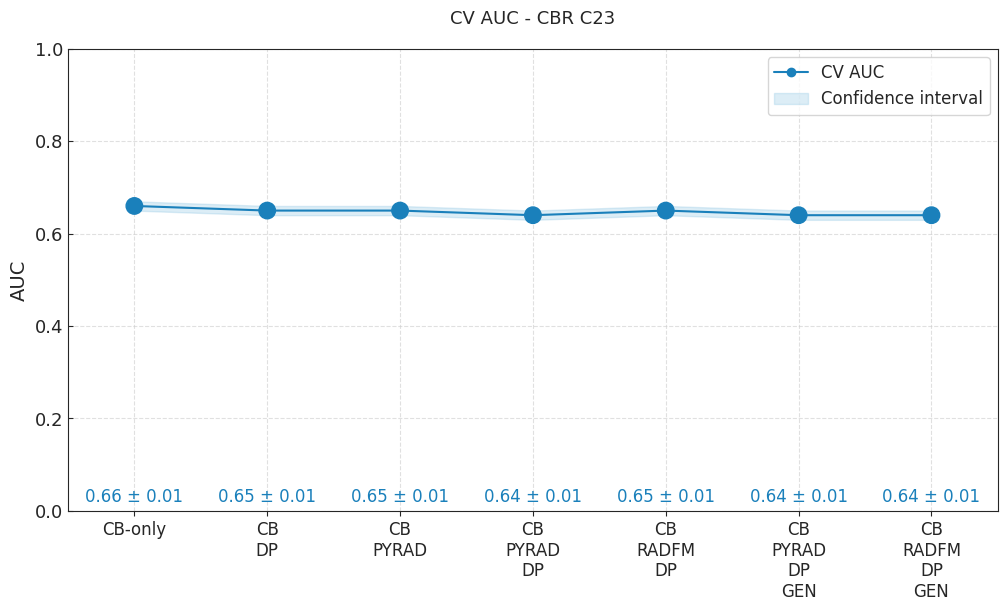

Saved: vanguri_CV_C23_CBR.png


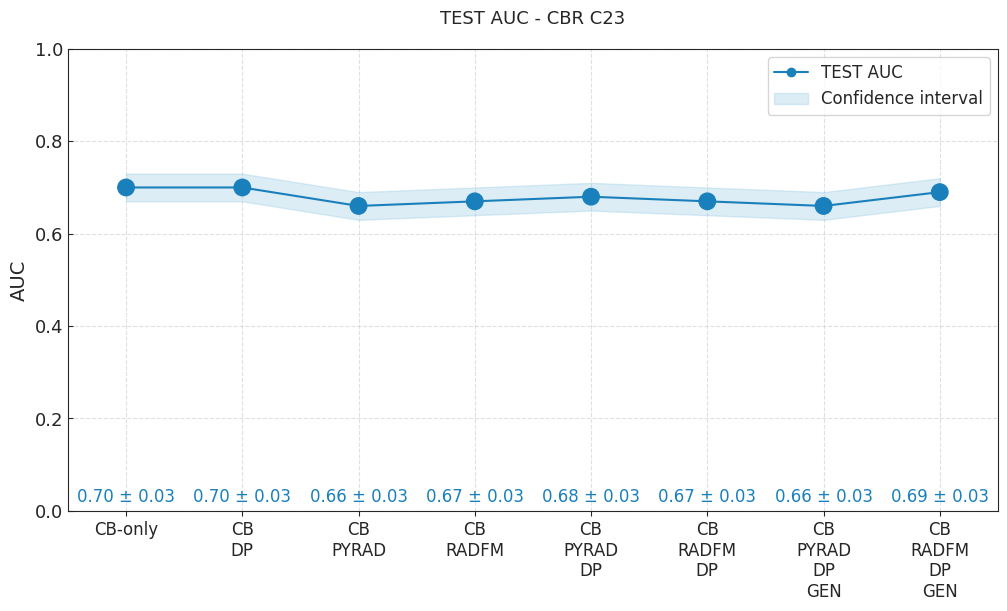

Saved: vanguri_TEST_C23_CBR.png


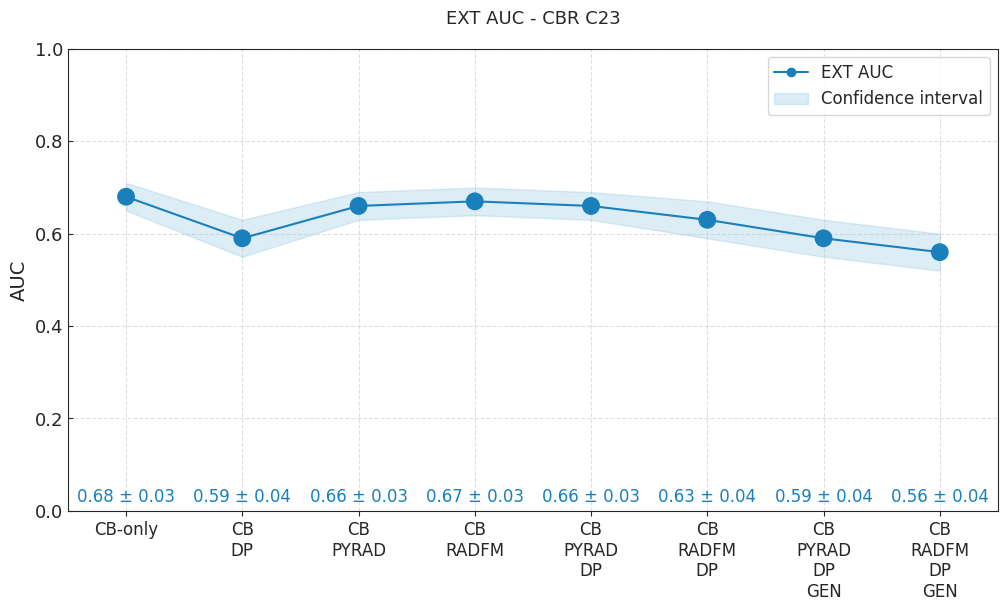

Saved: vanguri_EXT_C23_CBR.png


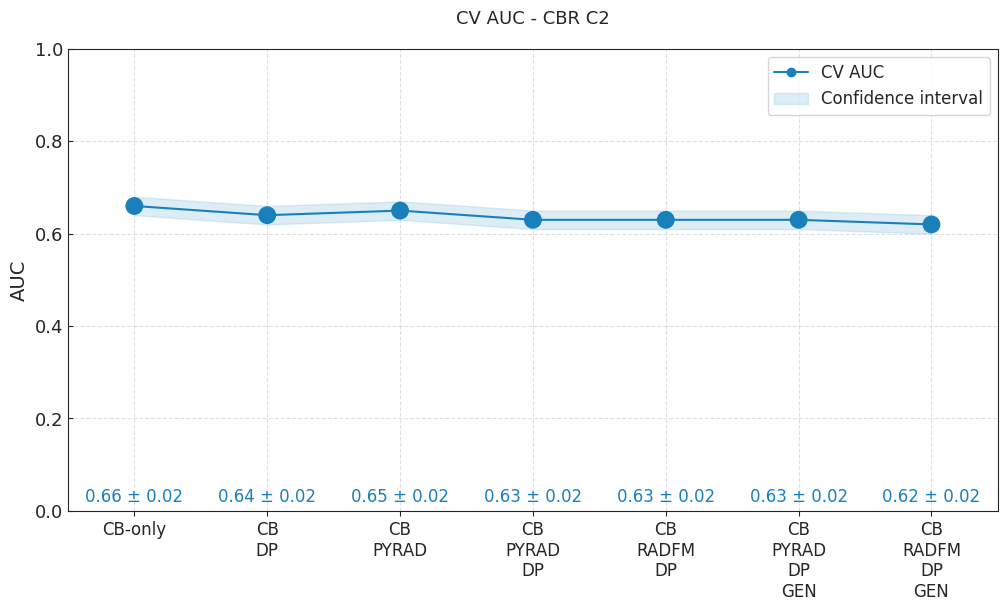

Saved: vanguri_CV_C2_CBR.png


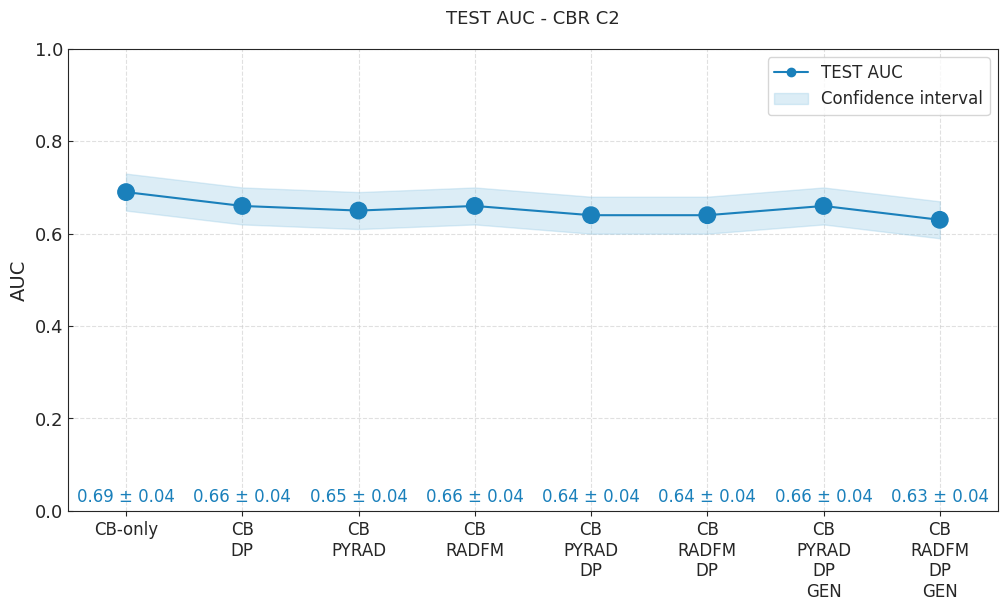

Saved: vanguri_TEST_C2_CBR.png


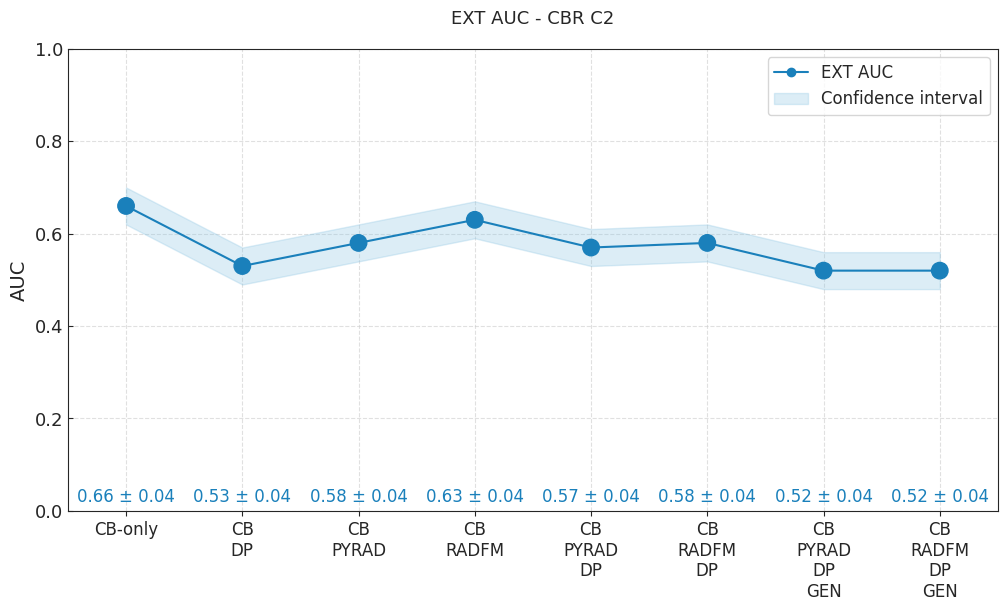

Saved: vanguri_EXT_C2_CBR.png

All plots saved to: results/plots


In [39]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Optional, Union


def scale_sizes(raw_sizes, min_bubble=30, max_bubble=250) -> np.ndarray:
    arr = np.array(list(raw_sizes), dtype=float)
    if arr.size == 0:
        return np.array([])
    if np.all(np.isnan(arr)):
        return np.full(arr.shape, (min_bubble + max_bubble) / 2.0)
    amin, amax = np.nanmin(arr), np.nanmax(arr)
    if not np.isfinite(amin) or not np.isfinite(amax) or (amax - amin < 1e-9):
        return np.full(arr.shape, (min_bubble + max_bubble) / 2.0)
    norm = (arr - amin) / (amax - amin + 1e-6)
    scaled = norm * (max_bubble - min_bubble) + min_bubble
    scaled[np.isnan(scaled)] = (min_bubble + max_bubble) / 2.0
    return scaled


def plot_one(
    analysis: str,
    rows: List[dict],
    arch_name: str,
    outcome: str,
    title_prefix: Optional[str] = None,
    show: bool = False,
    save_dir: Optional[Union[str, Path]] = None,
    label: Optional[str] = None,
    save_name: Optional[str] = None,
    min_bubble: float = 30,
    max_bubble: float = 250,
    dlif_eval_type: str = "standard",
) -> plt.Figure:
    modalities = [r["modality"] for r in rows]
    X = np.arange(len(modalities))

    auc_mod_mean = np.array([r["auc_mod_mean"] for r in rows], dtype=float)
    auc_mod_std  = np.array([r["auc_mod_std"]  for r in rows], dtype=float)
    n_train_mod  = np.array([r["n_train_mod"]  for r in rows], dtype=float)
    sizes        = scale_sizes(n_train_mod, min_bubble, max_bubble)
    model_names  = [r["model_mod"] for r in rows]

    fig = plt.figure(figsize=(12, 6))

    if label is None:
        if arch_name == "MLEF":
            label = "CV AUC"
        elif dlif_eval_type == "cross_validation":
            label = "CV AUC"
        elif dlif_eval_type == "evaluation":
            label = "Ext-Val AUC"
        else:
            label = "Test AUC"

    plt.plot(X, auc_mod_mean, linestyle="-", marker="o", label=label, color="#1a80bb")
    plt.scatter(X, auc_mod_mean, s=sizes if len(sizes) > 0 else 100, color="#1a80bb", zorder=3)
    plt.fill_between(X, auc_mod_mean - auc_mod_std, auc_mod_mean + auc_mod_std,
                     alpha=0.3, color="#8cc5e3", label="Confidence interval")

    multimodal_better = None

    if arch_name == "MLEF":
        auc_ro_mean = np.array([r["auc_ro_mean"] for r in rows], dtype=float)
        auc_ro_std  = np.array([r["auc_ro_std"]  for r in rows], dtype=float)
        plt.plot(X, auc_ro_mean, linestyle="-", marker="o", label="CV AUC - CB-only matched", color="#a00000")
        plt.scatter(X, auc_ro_mean, s=sizes if len(sizes) > 0 else 100, color="#a00000", zorder=3)
        plt.fill_between(X, auc_ro_mean - auc_ro_std, auc_ro_mean + auc_ro_std,
                         alpha=0.3, color="#d8a6a6", label="Confidence interval - CB-only matched")
        multimodal_better = (auc_mod_mean > auc_ro_mean)

    if arch_name == "DLIF":
        xticks = []
        for m, n in zip(modalities, n_train_mod):
            parts = m.split('_')
            parts = ['CB' if p == 'cb' else p for p in parts]
            xticks.append('\n'.join(parts))
        plt.xticks(X, xticks, rotation=0, fontsize=12)
    else:
        xticks = []
        for m, n in zip(modalities, n_train_mod):
            parts = m.replace('RWD', 'CB').split('_')
            xticks.append('\n'.join(parts))
        plt.xticks(X, xticks, rotation=0, fontsize=12)

    for i, (mval, mstd, mname) in enumerate(zip(auc_mod_mean, auc_mod_std, model_names)):
        base_y = 0.06 if (multimodal_better is not None and multimodal_better[i]) else 0.02
        if arch_name == "DLIF":
            plt.text(i, base_y, f"{mval:.2f} ± {mstd:.2f}",
                     fontsize=12, ha="center", color="#1a80bb")
        else:
            plt.text(i, base_y, f"{mval:.2f} ± {mstd:.2f} ({mname})",
                     fontsize=12, ha="center", color="#1a80bb")
        star = rows[i].get("stars", "")
        if star:
            plt.text(i + 0.40, base_y + 0.006, star, fontsize=12, ha="left", va="center", color="black")

    if arch_name == "MLEF":
        for i, rrow in enumerate(rows):
            rv, rs, rname = rrow["auc_ro_mean"], rrow["auc_ro_std"], rrow["model_ro"]
            base_y = 0.02 if multimodal_better[i] else 0.06
            if np.isfinite(rv) and np.isfinite(rs):
                plt.text(i, base_y, f"{rv:.2f} ± {rs:.2f} ({rname})",
                         fontsize=12, ha="center", color="#a00000")

    if arch_name == "MLEF":
        _auc_prefix = "CV AUC"
    elif dlif_eval_type == "cross_validation":
        _auc_prefix = "CV AUC"
    elif dlif_eval_type == "evaluation":
        _auc_prefix = "Ext-Val AUC"
    else:
        _auc_prefix = "Test AUC"

    ttl = title_prefix or f"{_auc_prefix} - {arch_name}"
    plt.title(f"{ttl} - {outcome} {analysis}", pad=18, fontsize=13, fontweight='normal')
    plt.ylabel("AUC", fontsize=14)
    plt.tick_params(axis='y', labelsize=13)
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=12)
    plt.xlim(-0.5, len(modalities) - 0.50)

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fname = f"{save_name}.png" if save_name else f"{ttl.replace(' ', '_')}_{outcome}_{analysis}.png"
        plt.savefig(Path(save_dir) / fname, dpi=600, bbox_inches="tight")
    if show:
        plt.show()
    return fig


def plot_vanguri_results(summary_xlsx='results/summary_all_results.xlsx', output_dir='results/plots',
                         min_bubble=30, max_bubble=250, show=True):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    df = pd.read_excel(summary_xlsx)

    modality_order = ['CB-only', 'CB_DP', 'CB_PYRAD', 'CB_RADFM',
                      'CB_PYRAD_DP', 'CB_RADFM_DP',
                      'CB_PYRAD_DP_GEN', 'CB_RADFM_DP_GEN']

    modality_map = {
    'CB-only': 'CB-only', 'CB_DP': 'CB_DP', 'CB_PYRAD': 'CB_PYRAD',
    'CB_RADFM': 'CB_RADFM', 'CB_PYRAD_DP': 'CB_PYRAD_DP',
    'CB_RADFM_DP': 'CB_RADFM_DP', 'CB_PYRAD_DP_GEN': 'CB_PYRAD_DP_GEN',
    'CB_RADFM_DP_GEN': 'CB_RADFM_DP_GEN'
    }
    
    modality_order = [modality_map[m] for m in modality_order]

    def _parse_auc(val):
        if pd.isna(val) or val == '':
            return np.nan, np.nan
        s = str(val).replace('+/-', '±')
        parts = [p.strip() for p in s.split('±')]
        try:
            return float(parts[0]), float(parts[1]) if len(parts) == 2 else 0.0
        except:
            return np.nan, np.nan

    for analysis in df['ANALYSIS'].unique():
        for outcome in df['OUTCOME'].unique():
            subset = df[(df['ANALYSIS'] == analysis) & (df['OUTCOME'] == outcome)]
            if subset.empty:
                continue

            subset = subset.set_index('MODALITY').reindex(modality_order).dropna(how='all').reset_index()
            if subset.empty:
                continue

            n_trains = pd.to_numeric(subset['n. train'], errors='coerce').values

            for set_type, auc_col, label in [
                ('CV', 'CV-AUC/CINDEX', 'CV AUC'),
                ('TEST', 'TEST-AUC/CINDEX', 'TEST AUC'),
                ('EXT', 'EXT-AUC/CINDEX', 'EXT AUC'),
            ]:
                parsed = [_parse_auc(v) for v in subset[auc_col]]
                means = np.array([p[0] for p in parsed])
                stds = np.array([p[1] for p in parsed])

                if np.all(np.isnan(means)):
                    continue

                rows = []
                for mod, mean, std, n in zip(subset['MODALITY'].values, means, stds, n_trains):
                    if not np.isfinite(mean):
                        continue
                    rows.append({
                        "modality": mod,
                        "auc_mod_mean": mean,
                        "auc_mod_std": std if np.isfinite(std) else 0.0,
                        "n_train_mod": n,
                        "model_mod": "Vanguri",
                    })

                if not rows:
                    continue

                fname = f"vanguri_{set_type}_{analysis}_{outcome}"
                plot_one(
                    analysis=analysis,
                    rows=rows,
                    arch_name="DLIF",
                    outcome=outcome,
                    title_prefix=label,
                    show=show,
                    label=label,
                    save_dir=output_dir,
                    save_name=fname,
                    min_bubble=min_bubble,
                    max_bubble=max_bubble,
                )
                print(f"Saved: {fname}.png")

    print(f"\nAll plots saved to: {output_dir}")


if __name__ == "__main__":
    plot_vanguri_results()